## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1. Load Data

In [2]:
tsla = pd.read_csv(
    "../data/processed/TSLA_cleaned.csv",
    index_col=0,
    parse_dates=True
)

bnd = pd.read_csv(
    "../data/processed/BND_cleaned.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

spy = pd.read_csv(
    "../data/processed/SPY_cleaned.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

# Remove MultiIndex columns
bnd.columns = bnd.columns.get_level_values(0)
spy.columns = spy.columns.get_level_values(0)

## Step 2. Create Backtesting Dataset

In [3]:
tsla_back = tsla.loc["2025-01-01":"2026-01-31"]
bnd_back = bnd.loc["2025-01-01":"2026-01-31"]
spy_back = spy.loc["2025-01-01":"2026-01-31"]

## Step 3. Compute Daily Returns

In [4]:
returns = pd.DataFrame()

returns["TSLA"] = tsla_back["Adj Close"].pct_change()
returns["BND"] = bnd_back["Adj Close"].pct_change()
returns["SPY"] = spy_back["Adj Close"].pct_change()

returns = returns.dropna()

## Step 4. Portfolio Weights

In [5]:
strategy_weights = np.array([
    0.00,
    0.54,
    0.45
])

In [6]:
benchmark_weights = np.array([
    0.00,
    0.40,
    0.60
])

## Step 5. Daily Portfolio Returns

In [7]:
strategy_returns = returns.dot(strategy_weights)

benchmark_returns = returns.dot(benchmark_weights)

## Step 6. Cumulative Returns

In [8]:
strategy_cumulative = (1 + strategy_returns).cumprod()

benchmark_cumulative = (1 + benchmark_returns).cumprod()

## Step 7. Plot Performance

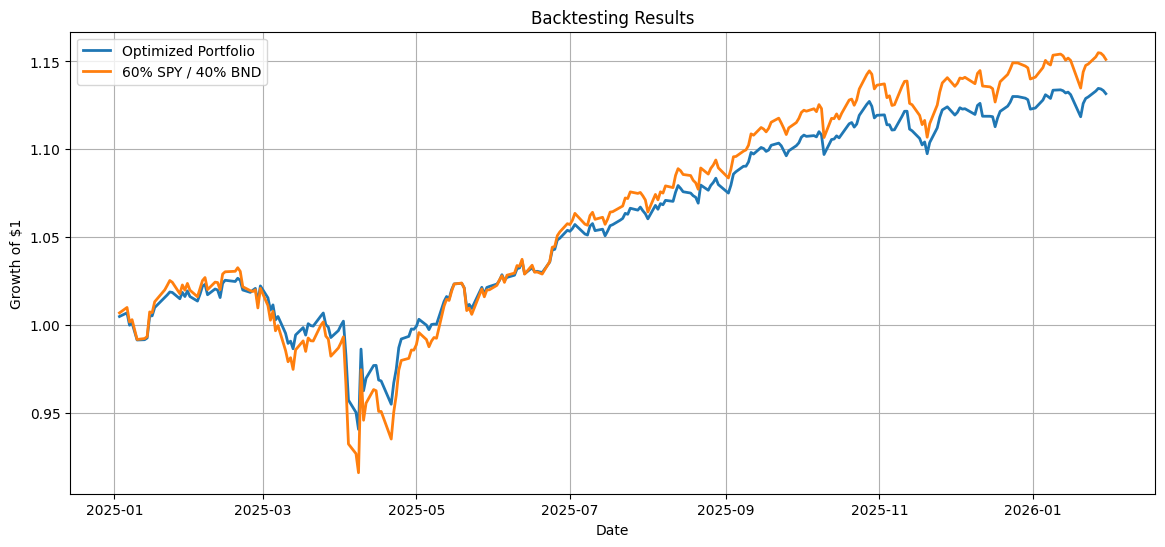

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    strategy_cumulative,
    label="Optimized Portfolio",
    linewidth=2
)

plt.plot(
    benchmark_cumulative,
    label="60% SPY / 40% BND",
    linewidth=2
)

plt.title("Backtesting Results")

plt.xlabel("Date")

plt.ylabel("Growth of $1")

plt.legend()

plt.grid(True)

plt.show()

## Step 8. Performance Metrics

### Total Return

In [10]:
strategy_total = strategy_cumulative.iloc[-1] - 1

benchmark_total = benchmark_cumulative.iloc[-1] - 1

### Annualized Return

In [11]:
days = len(strategy_returns)

strategy_annual = (1 + strategy_total) ** (252 / days) - 1

benchmark_annual = (1 + benchmark_total) ** (252 / days) - 1

### Sharpe Ratio

In [12]:
risk_free = 0.02

daily_rf = risk_free / 252

strategy_sharpe = np.sqrt(252) * (
    (strategy_returns.mean() - daily_rf)
    / strategy_returns.std()
)

benchmark_sharpe = np.sqrt(252) * (
    (benchmark_returns.mean() - daily_rf)
    / benchmark_returns.std()
)

### Maximum Drawdown

In [13]:
def max_drawdown(cumulative):

    rolling_max = cumulative.cummax()

    drawdown = (
        cumulative - rolling_max
    ) / rolling_max

    return drawdown.min()

In [14]:
strategy_drawdown = max_drawdown(
    strategy_cumulative
)

benchmark_drawdown = max_drawdown(
    benchmark_cumulative
)

## Step 9. Comparison Table

In [15]:
results = pd.DataFrame({

    "Strategy":[
        strategy_total,
        strategy_annual,
        strategy_sharpe,
        strategy_drawdown
    ],

    "Benchmark":[
        benchmark_total,
        benchmark_annual,
        benchmark_sharpe,
        benchmark_drawdown
    ]

},

index=[
    "Total Return",
    "Annualized Return",
    "Sharpe Ratio",
    "Maximum Drawdown"
])

results

,Strategy,Benchmark
Total Return,0.131677,0.151145
Annualized Return,0.122865,0.140951
Sharpe Ratio,1.101098,1.014986
Maximum Drawdown,-0.083712,-0.112888


## Step 10. Nicely Print Results

In [16]:
print(results.round(4))

                   Strategy  Benchmark
Total Return         0.1317     0.1511
Annualized Return    0.1229     0.1410
Sharpe Ratio         1.1011     1.0150
Maximum Drawdown    -0.0837    -0.1129
